## Конфигурация

Конфигурация Kubernetes включает в себя следующие компоненты:

1. `invoice-api`: `Бэкенд-сервис`, который обрабатывает запросы к инвойсам. Имеет 3 реплики и использует образ `backend-image`. Он также использует `ConfigMap` `store-config` и `Secret` `store-db-credentials`.

2. `online-store-frontend`: `Веб-сервис`, который служит фронтендом для онлайн-магазина. Имеет 3 реплики и использует образ `web-image`.

3. `sales-data-processor`: `Job`, который обрабатывает данные о продажах. Использует образ `data-handler-image`.

4. `old-invoices-cleaner`: `CronJob`, который очищает старые инвойсы. Запускается каждый день в полночь и использует образ `data-cleaner-image`.

5. `store-db`: `Deployment` для `базы данных Postgres`. Имеет 1 реплику и использует образ `postgres:latest`.

6. `store-message-queue`: `Deployment` для `RabbitMQ`, который используется как очередь сообщений. Имеет 1 реплику и использует образ `rabbitmq:latest`.

7. `payment-gateway-integration`: `Deployment` для интеграции с платежным шлюзом. Имеет 1 реплику и использует образ `external-service-image`.

`ConfigMap` и `Secret` используются для хранения конфигурации и секретных данных соответственно.

Конфигурация включает в себя следующие политики сети:

1. `allow-frontend-to-invoice-api`: Позволяет `Веб-сервису` общаться с `Бэкенд-сервисом`.

2. `allow-invoice-api-to-store-db`: Позволяет `Бэкенд-сервису` общаться с `базой данных Postgres`.

3. `allow-old-invoices-cleaner-to-store-db`: Позволяет `клинеру` общаться с `базой данных Postgres`.

4. `allow-payment-gateway-integration-to-invoice-api`: Позволяет `платежному шлюзу` общаться с `Бэкенд-сервисом`.

5. `allow-sales-data-processor-to-store-db`: Позволяет `обработчику данных о продажах` общаться с `базой данных Postgres`.

6. `allow-store-message-queue-to-invoice-api`: Позволяет `RabbitMQ` общаться с `Бэкенд-сервисом`.

7. `allow-web-traffic`: Открытвает внешний доступ к `Веб-сервису` через порт `TCP 80`.

## HLD диаграмма

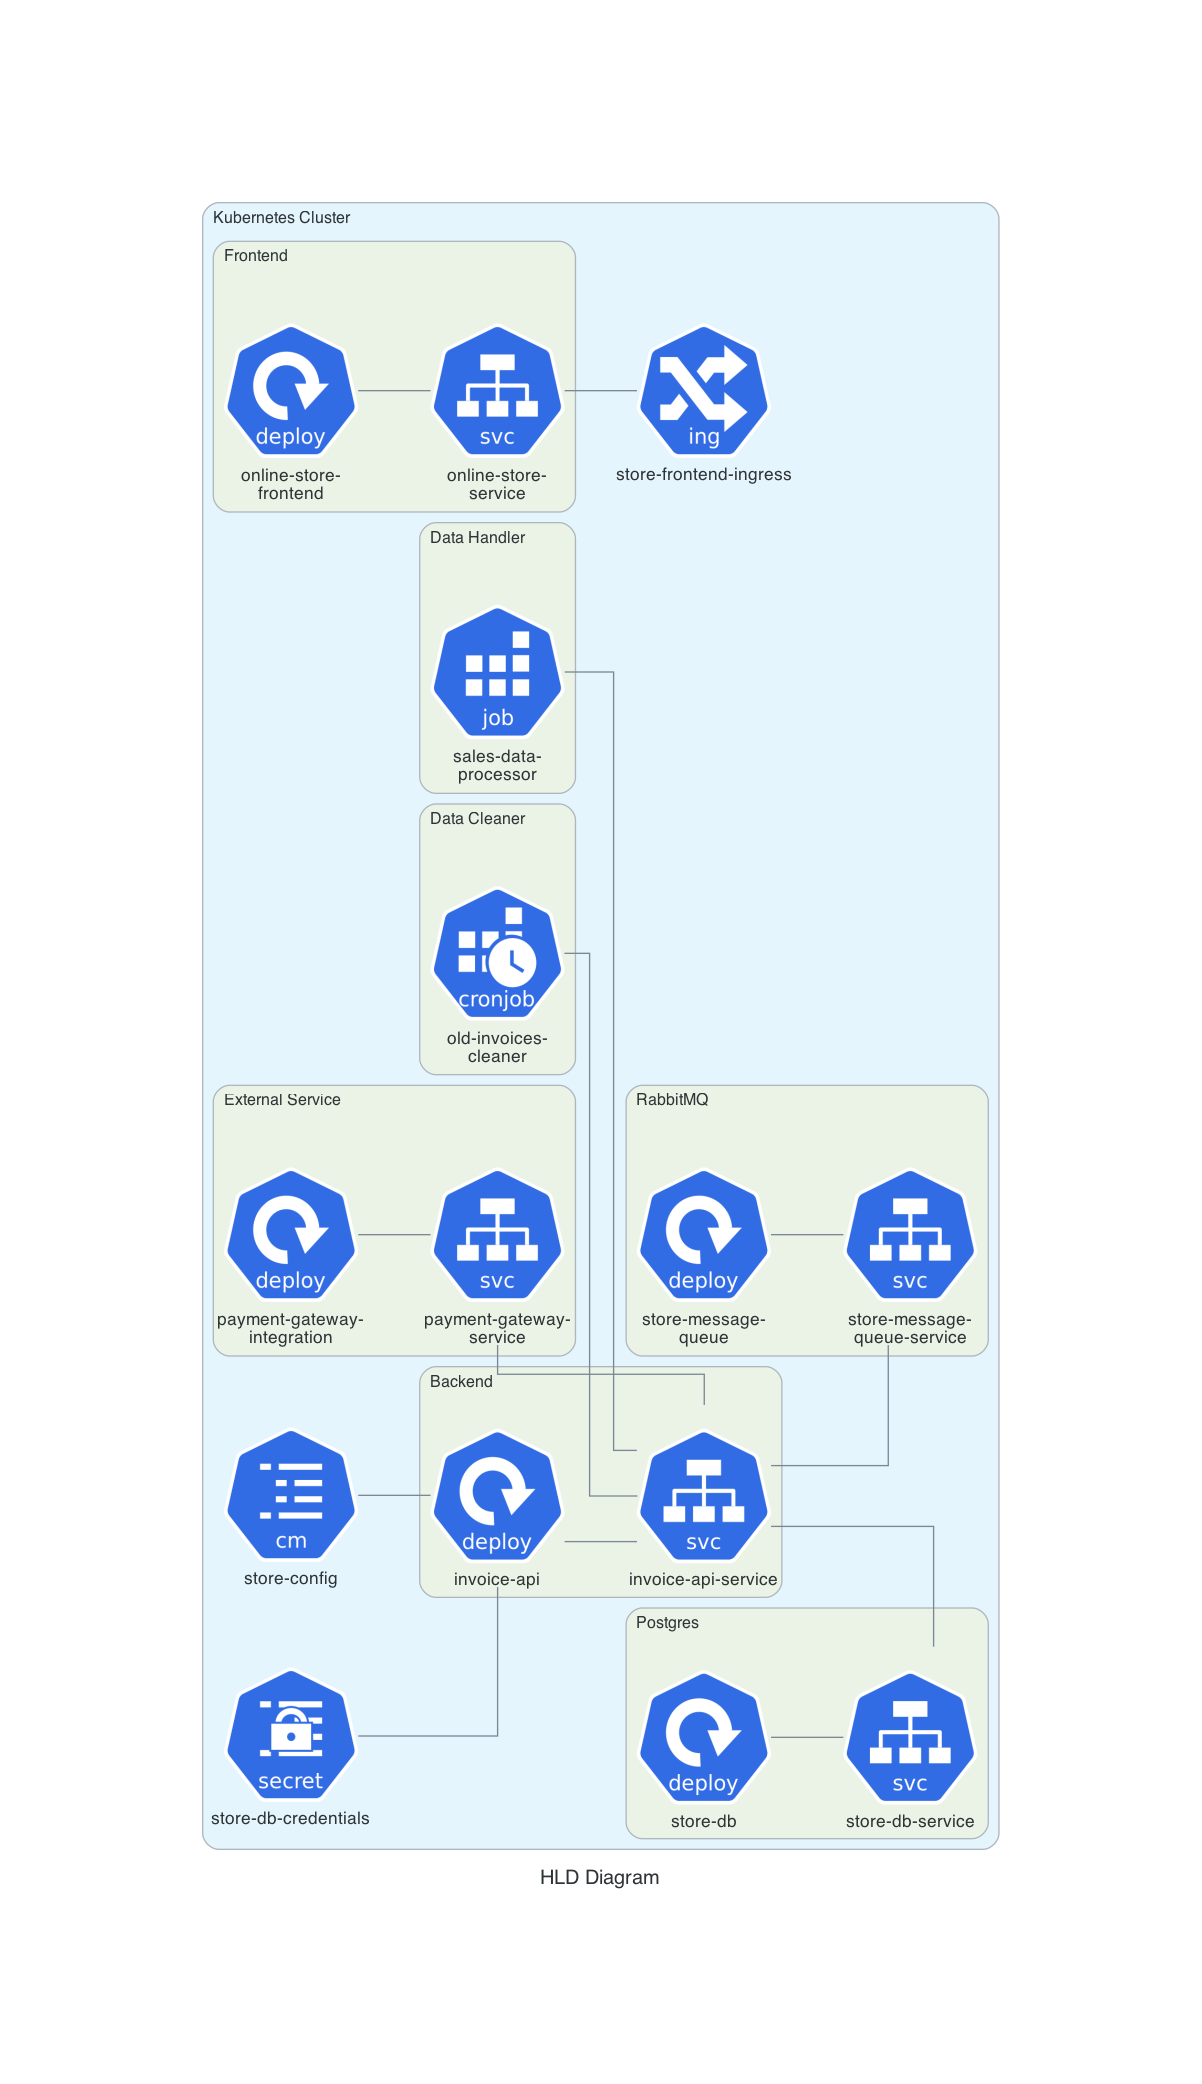

In [1]:
from diagrams import Cluster, Diagram
from diagrams.k8s.compute import Deployment, Job, Cronjob
from diagrams.k8s.network import Ingress, Service
from diagrams.k8s.podconfig import ConfigMap, Secret

with Diagram('HLD Diagram', show=False, graph_attr={'bgcolor': 'transparent'}) as diag:
    with Cluster('Kubernetes Cluster'):
        # ConfigMap, Secret
        config = ConfigMap('store-config')
        secret = Secret('store-db-credentials')

        # Backend
        with Cluster('Backend'):
            backend_deployment = Deployment('invoice-api')
            backend_service = Service('invoice-api-service')
            backend_deployment - backend_service

        # Frontend
        with Cluster('Frontend'):
            frontend_deployment = Deployment('online-store-\nfrontend')
            frontend_service = Service('online-store-\nservice')
            frontend_deployment - frontend_service

        # Data Handler
        with Cluster('Data Handler'):
            data_handler_job = Job('sales-data-\nprocessor')

        # Data Cleaner
        with Cluster('Data Cleaner'):
            data_cleaner_cronjob = Cronjob('old-invoices-\ncleaner')

        # Ingress
        ingress = Ingress('store-frontend-ingress')

        # Postgres
        with Cluster('Postgres'):
            postgres_deployment = Deployment('store-db')
            postgres_service = Service('store-db-service')
            postgres_deployment - postgres_service

        # RabbitMQ
        with Cluster('RabbitMQ'):
            rabbitmq_deployment = Deployment('store-message-\nqueue')
            rabbitmq_service = Service('store-message-\nqueue-service')
            rabbitmq_deployment - rabbitmq_service

        # External Service
        with Cluster('External Service'):
            external_service_deployment = Deployment('payment-gateway-\nintegration')
            external_service_service = Service('payment-gateway-\nservice')
            external_service_deployment - external_service_service

        # ConfigMap, Secret >> Backend Deployment
        config - backend_deployment
        secret - backend_deployment

        # Services >> Ingress
        frontend_service - ingress

        # Backend >> Postgres, RabbitMQ
        backend_service - postgres_service
        backend_service - rabbitmq_service

        # Data Handler, Data Cleaner >> Backend
        data_handler_job - backend_service
        data_cleaner_cronjob - backend_service

        # External Service >> Backend
        external_service_service - backend_service

diag

## Test

In [2]:
!kubectl version

Client Version: v1.28.2
Kustomize Version: v5.0.4-0.20230601165947-6ce0bf390ce3
Server Version: v1.28.2


In [3]:
!kubectl apply -f yml/

networkpolicy.networking.k8s.io/allow-frontend-to-invoice-api unchanged
networkpolicy.networking.k8s.io/allow-invoice-api-to-store-db unchanged
networkpolicy.networking.k8s.io/allow-old-invoices-cleaner-to-store-db unchanged
networkpolicy.networking.k8s.io/allow-payment-gateway-integration-to-invoice-api unchanged
networkpolicy.networking.k8s.io/allow-sales-data-processor-to-store-db unchanged
networkpolicy.networking.k8s.io/allow-store-message-queue-to-invoice-api unchanged
networkpolicy.networking.k8s.io/allow-web-traffic unchanged
configmap/invoice-api-config created
service/invoice-api-service created
deployment.apps/invoice-api created
cronjob.batch/old-invoices-cleaner created
deployment.apps/online-store-frontend created
service/online-store-service created
deployment.apps/payment-gateway-integration created
service/payment-gateway-service created
job.batch/sales-data-processor created
configmap/store-config unchanged
secret/store-db-credentials unchanged
service/store-db-servic

In [4]:
!kubectl delete all --all --all-namespaces

pod "invoice-api-6dc5756db5-bw7cm" deleted
pod "invoice-api-6dc5756db5-tjzkj" deleted
pod "invoice-api-6dc5756db5-vhzvh" deleted
pod "online-store-frontend-7f596999f-cg8j2" deleted
pod "online-store-frontend-7f596999f-p6pxz" deleted
pod "online-store-frontend-7f596999f-qj2wq" deleted
pod "payment-gateway-integration-69846c6f-chdn6" deleted
pod "sales-data-processor-dk7t4" deleted
pod "store-db-5c9b9c5755-tmggf" deleted
pod "store-message-queue-d8c48b6dd-g99nq" deleted
pod "etcd-docker-desktop" deleted
pod "kube-apiserver-docker-desktop" deleted
pod "kube-controller-manager-docker-desktop" deleted
pod "kube-scheduler-docker-desktop" deleted
service "invoice-api-service" deleted
service "kubernetes" deleted
service "online-store-service" deleted
service "payment-gateway-service" deleted
service "store-db-service" deleted
service "store-message-queue-service" deleted
deployment.apps "invoice-api" deleted
deployment.apps "online-store-frontend" deleted
deployment.apps "payment-gateway-inte